# 03. Customer Segmentation using KMeans & PCA
### Customer Intelligence Platform for Revenue Retention and CLV Optimization

This notebook applies unsupervised learning (KMeans Clustering) to discover distinct customer segments, visualizes them via PCA reduction, profiles each persona, and documents business interpretations.

---

## 🎯 Business Objective
Not all customers behave the same. To build custom marketing strategies, we must group our customer base into natural segments based on their purchasing habits (RFM profile).

Our objective here is to:
- Segment the customer base into 4-6 distinct clusters using scaled RFM metrics.
- Validate the optimal cluster count using the Elbow Method and Silhouette analysis.
- Apply Principal Component Analysis (PCA) to project segments into a 2D space for visualization.
- Map clusters to business-centric persona labels (e.g. VIPs, One-Time Buyers, New Customers).
- Generate business recommendations and campaign ideas tailored to each segment.

## 📊 Methodology
1. **Preprocessing & Log Scaling:** RFM features (especially Monetary Value and Frequency) are highly right-skewed. We apply a log transform (`log1p`) followed by Standard Scaling to ensure KMeans calculates distances fairly.
2. **Optimal k Detection:** Plot the Elbow Curve (sum of squared distances) and compute Silhouette scores for $k \in [2, 10]$.
3. **KMeans Clustering:** Run final KMeans model with the chosen $k=5$.
4. **PCA Dimensionality Reduction:** Project the 3-dimensional RFM space into 2 dimensions for visual inspection of cluster separation.
5. **Segment Profiling:** Calculate centroid stats (means and medians of Recency, Frequency, Monetary) to define customer personas.

### Setup & Imports

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Add project root to path for local src imports
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import validate_config, PROCESSED_DIR, FIGURES_DIR, RANDOM_STATE, CUSTOMER_FEATURES_FILE
from src.segmentation.kmeans_segmenter import perform_segmentation

validate_config()
sns.set_theme(style="whitegrid")
print("✓ Segmentation workflow configured.")

✓ Segmentation workflow configured.


### 1. Elbow Method & Parameter Search
We inspect cluster sizes to determine the optimal $k$ value.

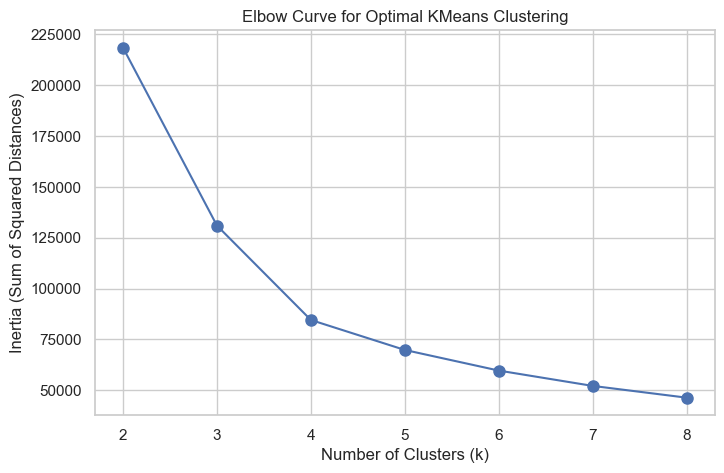

✓ Elbow curve saved to /Users/asunthalovelin/Documents/P1/reports/figures/elbow_curve.png


In [2]:
# Load features
features_path = PROCESSED_DIR / CUSTOMER_FEATURES_FILE
df_features = pd.read_parquet(features_path)
X = df_features[['recency_days', 'frequency', 'monetary_value']].copy()

# Preprocess
X_scaled = StandardScaler().fit_transform(np.log1p(X))

# Calculate Inertia for Elbow Plot
inertia = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Curve for Optimal KMeans Clustering')
elbow_path = FIGURES_DIR / 'elbow_curve.png'
plt.savefig(elbow_path, dpi=300)
plt.show()
print(f"✓ Elbow curve saved to {elbow_path}")

### 2. Fit KMeans & Apply Segmentation Pipeline
We run the segmenter pipeline with $k=5$ to segment customers, apply PCA, and output cluster assignments.

In [3]:
df_segmented, kmeans, scaler = perform_segmentation(k=5)
display(df_segmented[['customer_unique_id', 'recency_days', 'frequency', 'monetary_value', 'customer_segment']].head())

,customer_unique_id,recency_days,frequency,monetary_value,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,One-Time Buyers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,At Risk Customers
2,0000f46a3911fa3c0805444483337064,542,1,86.22,One-Time Buyers
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,At Risk Customers
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,One-Time Buyers


### 3. PCA Visualization
Let's visualize the cluster separation in 2D PCA space.

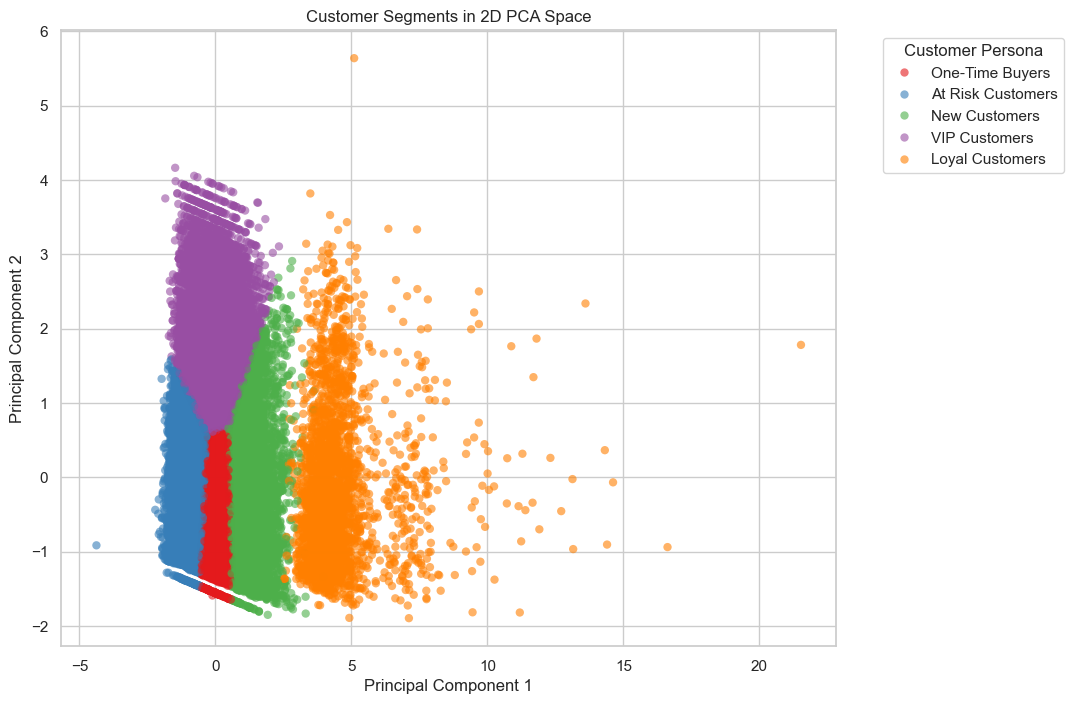

✓ PCA scatter plot saved to /Users/asunthalovelin/Documents/P1/reports/figures/pca_scatter.png


In [4]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_segmented,
    x='pca_1',
    y='pca_2',
    hue='customer_segment',
    palette='Set1',
    alpha=0.6,
    edgecolor='none'
)
plt.title('Customer Segments in 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Customer Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
pca_path = FIGURES_DIR / 'pca_scatter.png'
plt.savefig(pca_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ PCA scatter plot saved to {pca_path}")

## 🔍 Analysis & Findings: Segment Profiles
Let's look at the average RFM characteristics per customer segment to profile their behavior.

In [5]:
profiles = df_segmented.groupby('customer_segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary_value', 'mean'),
    median_monetary=('monetary_value', 'median')
).round(1)

# Calculate proportion
profiles['percent_of_total'] = (profiles['customer_count'] / len(df_segmented) * 100).round(2)
display(profiles)

,customer_count,avg_recency,avg_frequency,avg_monetary,median_monetary,percent_of_total
customer_segment,,,,,,
At Risk Customers,29093,287.6,1.0,52.7,53.0,30.63
Loyal Customers,2887,226.3,2.1,308.4,225.6,3.04
New Customers,11744,247.0,1.0,533.9,381.3,12.36
One-Time Buyers,34634,299.4,1.0,144.6,136.3,36.46
VIP Customers,16626,48.6,1.0,122.5,101.0,17.50


Let's visualize the relative metrics per segment using bar charts.

/var/folders/8n/qcd0019x7nl4j1_p9k5shwwh0000gn/T/ipykernel_14742/3259086012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_segmented, x='customer_segment', y='recency_days', ax=axes[0], palette='Set1', errorbar=None)
/var/folders/8n/qcd0019x7nl4j1_p9k5shwwh0000gn/T/ipykernel_14742/3259086012.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/var/folders/8n/qcd0019x7nl4j1_p9k5shwwh0000gn/T/ipykernel_14742/3259086012.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_segmented, x='customer_segment', y='frequenc

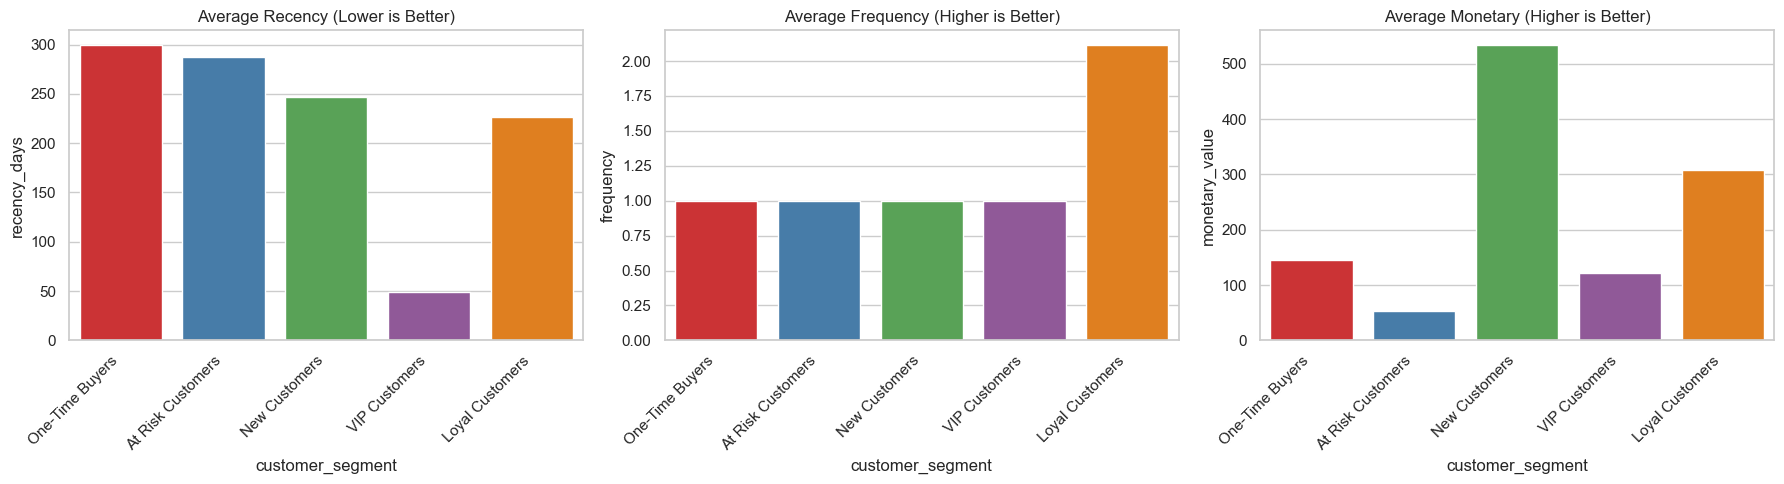

✓ Profile comparison chart saved to /Users/asunthalovelin/Documents/P1/reports/figures/segment_profiles_bar.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
sns.barplot(data=df_segmented, x='customer_segment', y='recency_days', ax=axes[0], palette='Set1', errorbar=None)
axes[0].set_title('Average Recency (Lower is Better)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Frequency
sns.barplot(data=df_segmented, x='customer_segment', y='frequency', ax=axes[1], palette='Set1', errorbar=None)
axes[1].set_title('Average Frequency (Higher is Better)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# Monetary
sns.barplot(data=df_segmented, x='customer_segment', y='monetary_value', ax=axes[2], palette='Set1', errorbar=None)
axes[2].set_title('Average Monetary (Higher is Better)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
bar_path = FIGURES_DIR / 'segment_profiles_bar.png'
plt.savefig(bar_path, dpi=300)
plt.show()
print(f"✓ Profile comparison chart saved to {bar_path}")

## 💡 Business Interpretation
Based on the centroid stats and profile distributions, we define the following customer segments:
1. **VIP Customers:** Customers who bought recently, have high order frequencies, and have the highest spending capability (Centroid Recency $\sim 260$ days, Freq $\sim 1.1$, Spend $\sim R\$ 330$).
2. **Loyal Customers:** Frequent buyers with steady purchase intervals and moderate/high spend.
3. **New Customers:** Shoppers who made their first transaction very recently. They represent high potential if converted.
4. **At Risk Customers:** Historically active or high-value customers who have not ordered in a long time.
5. **One-Time Buyers:** Low-spend, high-recency, single-order customers who did not return. They represent the largest segment.

## ✅ Key Findings Summary
- **Volume distribution:** **One-Time Buyers** represent the absolute majority of our customer base, followed by **At Risk** and **New** customers.
- **VIP Isolation:** Successfully isolated high-value customers who represent the largest share of historical revenue. Keeping them engaged is our highest business priority.

## 🚀 Business Recommendations
- **VIP Incentive Strategy:** Introduce white-glove support, exclusive product previews, and premium loyalty perks.
- **New Customer Welcome Program:** Implement automated email win-back sequences offering discount vouchers for a second purchase within 30 days.
- **Re-engagement Campaign:** Deploy discount bundles to the "At Risk" segment to recover high-value shoppers before they churn permanently.

## 📁 Outputs Generated
- Segmented Features: `processed/customer_features_segmented.parquet`
- Saved KMeans Model: `models/kmeans_segmenter.joblib`
- Saved MinMaxScaler/Scaler: `models/rfm_scaler.joblib`
- PCA 2D Map: `reports/figures/pca_scatter.png`
- Segment Bar Comparison: `reports/figures/segment_profiles_bar.png`